In [ ]:
# Google Colab is recommended for running this notebook.
# Here are the steps to get this program running:
# 1. Start the Colab notebook and open the Files tab.
# 2. Make sure you are in the "content" folder (the folder with the "sample_data" folder)
# 3. In the "content" folder, create two folders named train_data and test_data
# 4. You should have a zipped file with data that has either the word "train" or "test" in its name.
# Put the "train" data in the train_data folder and the "test" data in the test_data folder.
# 5. Run the code cell that says "Train Phase." It will create word sentiment weights that can then be used for determining sentiment of topics.
# 6. Run the code cell with the "is_noun_or_unknown" function, which is needed for the test phase.
# 7. Run the code cell that says "Test Phase." This is where the program determines the average sentiment of topics/subtopics
# by category with 10,000 reviews for each category.
# 8. After running the Test Phase code cell, you can run other code cells to create various charts.
# You can create a top 10 most positive/negative topics by category or create bar graphs representing the score of a specific word for each category.
# 9. You are also able to find the sentiment of words using only one review by running the last code cell and specifying
# the review's title and text.

In [ ]:
# Note: Some lines of code that are commented out are there for the purpose of debugging.

# Category legend (train_data): acs=Arts Crafts and Sewing, books=Books, cpa=Cell Phones and Accessories,
# csj=Clothing Shoes and Jewelry, electr=Electronics, hk=Home and Kitchen, matv=Movies and TV,
# spo=Sports and Outdoors, thi=Tools and Home Improvement, vg=Video Games

# Category legend (test_data): books=Books, cpa=Cell Phones and Accessories, ggf=Grocery and Gourmet Food,
# hk=Home and Kitchen, matv=Movies and TV, plg=Patio Lawn and Garden

# Refer to my google slides presentation for more information on this program.

In [ ]:
# Train Phase
# This code cell uses multiple CSV files to create word sentiment weights.
# This code is to make it so this program learns the sentiment of all words (except stop words).

# import and download the required libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import csv
import os
from nltk.corpus import wordnet as wn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nltk.download("wordnet")
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

# create list of stop words
stop_words_list = list(stopwords.words("english"))
stop_words_list = stop_words_list + ["/", ".", ",", ";", "?", ">", "<", ":", "|", "[", "]", "{", "}",
                                     "(", ")", "!", "br"]

train_data = os.listdir("train_data")

print(train_data)

sentiment_dict = {}

# start analyzing the review data
for name in train_data:
  dir = "train_data/" + name
  print(f"Now analyzing {dir}")

  csv_file = open(dir, 'r')
  csv_reader = csv.reader(csv_file)

  read_fields = next(csv_reader)
  read_rows = []
  for row in csv_reader:
    read_rows.append(row)

  # print(read_rows)

  csv_file.close()

  # start analyzing a review
  for review in read_rows:
    w_weight = 0
    if review[0] == "1.0":
      w_weight = -35
    elif review[0] == "2.0":
      w_weight = -20
    elif review[0] == "3.0":
      w_weight = -10
    elif review[0] == "4.0":
      w_weight = 3
    else:
      w_weight = 10

    # tokenize the review's title and text
    rev_title = word_tokenize(review[1].lower())
    rev_text = word_tokenize(review[2].lower())

    # in the review title and text, add to a cumulative sum of weights for each eligible word.
    for word in rev_title:
      if word not in stop_words_list:
        if word not in sentiment_dict:
          sentiment_dict[word] = [w_weight, 1]
        else:
          sentiment_dict[word][0] += w_weight
          sentiment_dict[word][1] += 1

    for word in rev_text:
      if word not in stop_words_list:
        if word not in sentiment_dict:
          sentiment_dict[word] = [w_weight, 1]
        else:
          sentiment_dict[word][0] += w_weight
          sentiment_dict[word][1] += 1

# append the average into the sentiment dictionary
for node in sentiment_dict:
  sentiment_dict[node].append(sentiment_dict[node][0] / sentiment_dict[node][1])

# filter the dictionary for more useful words
f_sentiment_dict = {node : sentiment_dict[node] for node in sentiment_dict if sentiment_dict[node][1] > 140}

# display the results
print(sorted(f_sentiment_dict.items(), key = lambda d: d[1][2]))
print(sorted(f_sentiment_dict.items(), key = lambda d: -d[1][2]))

# put the model's values into a CSV file
data_list = [[node, f_sentiment_dict[node][0], f_sentiment_dict[node][1], f_sentiment_dict[node][2]] for node in f_sentiment_dict]

csv_fields = ["Word", "Sum", "Occurrences", "Average"]

# write the entire sentiment dictionary into a CSV file. The resulting file represents the drastic difference between the sizes of the training data and the model's weights.
with open("write_dict_into_csv.csv", 'w') as f:
    csv_writer = csv.writer(f)
    csv_writer.writerow(csv_fields)
    csv_writer.writerows(data_list)

# In the list corresponding to each word, the first value is the sentiment sum, the second value is the number of times the word was encountered,
# and the third value is the word's overall sentiment value.

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['csj_csv_train.csv', 'cpa_csv_train.csv', 'hk_csv_train.csv', 'vg_csv_train.csv', 'electr_csv_train.csv', 'books_csv_train.csv', 'matv_csv_train.csv', 'acs_csv_train.csv', 'spo_csv_train.csv', 'thi_csv_train.csv']
Now analyzing train_data/csj_csv_train.csv
Now analyzing train_data/cpa_csv_train.csv
Now analyzing train_data/hk_csv_train.csv
Now analyzing train_data/vg_csv_train.csv
Now analyzing train_data/electr_csv_train.csv
Now analyzing train_data/books_csv_train.csv
Now analyzing train_data/matv_csv_train.csv
Now analyzing train_data/acs_csv_train.csv
Now analyzing train_data/spo_csv_train.csv
Now analyzing train_data/thi_csv_train.csv
[('junk', [-25469, 1090, -23.36605504587156]), ('waste', [-64544, 2766, -23.33477946493131]), ('worthless', [-6541, 286, -22.87062937062937]), ('refund', [-13025, 589, -22.113752122241088]), ('garbage', [-18732, 856, -21.88317757009346]), ('crap', [-12266, 601, -20.409317803660567]), ('defective', [-14028, 705, -19.897872340425533]), ('unusable', [-

In [ ]:
# test phase will need this function, run this cell too
def is_noun_or_unknown(word):
  # words unknown to wordnet automatically pass
  if wn.synsets(word) == []:
    return True
  else:
    # words with a high enough percentage of noun synsets to all of its synsets (>59%) pass
    noun_num = 0
    other_num = 0
    for syn in wn.synsets(word):
      if ".n." in str(syn):
        noun_num += 1
      else:
        other_num += 1
    if noun_num / (noun_num + other_num) > 0.59:
      return True
    else:
      return False

In [ ]:
# Test Phase
# This testing code uses sentiment_dict to determine the sentiment of nouns in a set of reviews
# It is recommended to test sets of reviews of single categories for better analysis of specific product markets

test_data = os.listdir("test_data")

print(test_data)

all_ld_dicts_n = []
all_ld_dicts_p = []
like_dislike_dict = {}

# Go to every file in the test_data folder
for name in test_data:
  like_dislike_dict = {}
  dir = "test_data/" + name
  print(f"Now analyzing {dir}")

  try:
    csv_file = open(dir, 'r')
  except IsADirectoryError:
    continue

  csv_reader = csv.reader(csv_file)

  read_fields = next(csv_reader)
  read_rows = []
  for row in csv_reader:
      read_rows.append(row)

  # print(read_rows)

  csv_file.close()

  # minimum word occurrence for sect[j] to consider and consider word threshold for sect[i] to consider
  min_word_occurrence = 140
  consider_word_threshold = sorted(f_sentiment_dict.items(), key=lambda d: -d[1][1])[0][1][1] + 1
  # print(consider_word_threshold)

  rev_count = 0
  # start reading through the reviews in a file
  for rev in read_rows:
    # create tokenized instances of review title and text
    rev_tokens = [word_tokenize(rev[1].lower()), word_tokenize(rev[2].lower())]
    sect_num = 0
    for sect in rev_tokens:
      # evaluate the sentiment of the target word
      for i in range(len(sect)):
        # evaluate for noun or unknown word
        if is_noun_or_unknown(sect[i]):
          if sect[i] not in stop_words_list:
            if (sect[i] not in f_sentiment_dict) or (f_sentiment_dict[sect[i]][1] < consider_word_threshold):
              # use the sentiment of surrounding words to weigh the target word
              for j in range(len(sect)):
                try:
                  if (sect[j] not in stop_words_list) and (sect[j] in f_sentiment_dict):
                    if sect[i] not in like_dislike_dict:
                      if f_sentiment_dict[sect[j]][1] > min_word_occurrence:
                        like_dislike_dict[sect[i]] = [f_sentiment_dict[sect[j]][2] / 2**(abs(i - j)), 1]
                    else:
                      if f_sentiment_dict[sect[j]][1] > min_word_occurrence:
                      # print(sect[i], like_dislike_dict[sect[i]])
                        like_dislike_dict[sect[i]][0] += f_sentiment_dict[sect[j]][2] / (2**(abs(i - j)))
                        like_dislike_dict[sect[i]][1] += 1
                      # print(sect[i], like_dislike_dict[sect[i]])
                except OverflowError:
                  # print("Overflow encountered while processing " + str(sect[j]) + " for " + str(sect[i]))
                  break
              if sect_num == 1:
                for j in range(len(rev_tokens[0])):
                  try:
                    if (rev_tokens[0][j] not in stop_words_list) and (rev_tokens[0][j] in f_sentiment_dict):
                      if sect[i] not in like_dislike_dict:
                        if f_sentiment_dict[rev_tokens[0][j]][1] > min_word_occurrence:
                          like_dislike_dict[sect[i]] = [f_sentiment_dict[rev_tokens[0][j]][2], 1]
                      else:
                        if f_sentiment_dict[rev_tokens[0][j]][1] > min_word_occurrence:
                        # print(sect[i], like_dislike_dict[sect[i]])
                          like_dislike_dict[sect[i]][0] += f_sentiment_dict[rev_tokens[0][j]][2]
                          like_dislike_dict[sect[i]][1] += 1
                        # print(sect[i], like_dislike_dict[sect[i]])
                  except OverflowError:
                    # print("Overflow encountered while processing " + str(rev_tokens[0][j]) + " for " + str(sect[i]))
                    break
      sect_num += 1
    # print(rev_count)
    rev_count += 1

  # append the averages of words into the dictionary
  for node in like_dislike_dict:
    like_dislike_dict[node].append(like_dislike_dict[node][0] / like_dislike_dict[node][1])

  # filter the dictionary so there are less irrelevant words
  f_like_dislike_dict = {node : like_dislike_dict[node] for node in like_dislike_dict if like_dislike_dict[node][1] > 350}

  # display the results
  # print(like_dislike_dict.items())
  # The same topic sentiment dictionary is printed twice, but one is sorted from most negative to most positive
  # and the other is vice versa.
  print(sorted(f_like_dislike_dict.items(), key = lambda d: d[1][2]))
  print(sorted(f_like_dislike_dict.items(), key = lambda d: -d[1][2]))

  all_ld_dicts_n.append(sorted(f_like_dislike_dict.items(), key = lambda d: d[1][2]))
  all_ld_dicts_p.append(sorted(f_like_dislike_dict.items(), key = lambda d: -d[1][2]))

# In the list corresponding to each word/topic, the first value is the sentiment sum, the second value is the number of times the sentiment sum was modified,
# and the third value is the word's average sentiment value across the test data for the category.


['plg_csv_test.csv', 'ggf_csv_test.csv', 'cpa_csv_test.csv', 'matv_csv_test.csv', 'books_csv_test.csv', 'hk_csv_test.csv']
Now analyzing test_data/plg_csv_test.csv
[('junk', [-2620.4977704065427, 2352, -1.1141572153089043]), ('crap', [-767.9551505599518, 772, -0.9947605577201448]), ('buyer', [-279.8405422549027, 627, -0.4463166543140394]), ('nope', [-220.0916472688355, 537, -0.409854091748297]), ('garbage', [-792.2837722480064, 2340, -0.33858280865299417]), ('refund', [-966.860858024639, 2938, -0.3290881068838118]), ('trash', [-513.3617694336455, 1616, -0.3176743622732955]), ('money', [-2720.7511854724876, 10679, -0.2547758390741163]), ('joke', [-179.43389737065837, 869, -0.20648319605369203]), ('disappointment', [-216.18840127608883, 1150, -0.18798991415312072]), ('nightmare', [-74.39930993199714, 421, -0.17672045114488633]), ('ugh', [-96.45083640059589, 574, -0.1680328160289127]), ('response', [-80.43740160972946, 1435, -0.056053938403992656]), ('underquilt', [-26.449355970671505, 51

In [ ]:
# create a pandas table after finding what reviewers like and dislike
# the pandas table is sorted from highest to lowest sentiment, so it's basically a top 10 (mostly) topics

dict_to_df_p = [[(all_ld_dicts_p[i][j][0], all_ld_dicts_p[i][j][1][2]) for j in range(len(all_ld_dicts_p[i]))] for i in range(len(all_ld_dicts_p))]
dict_to_df_n = [[(all_ld_dicts_n[i][j][0], all_ld_dicts_n[i][j][1][2]) for j in range(len(all_ld_dicts_n[i]))] for i in range(len(all_ld_dicts_n))]

test_data_pfixs = [name.split("_")[0] for name in test_data if ".ipynb" not in name]

ld_df_p = pd.DataFrame(dict_to_df_p, index = test_data_pfixs, columns = np.arange(1, max([len(all_ld_dicts_p[i]) for i in range(len(all_ld_dicts_p))])+1))
ld_df_n = pd.DataFrame(dict_to_df_n, index = test_data_pfixs, columns = np.arange(1, max([len(all_ld_dicts_n[i]) for i in range(len(all_ld_dicts_n))])+1))
ld_df_p


,1,2,3,4,5,6,7,8,9,10,...,3930,3931,3932,3933,3934,3935,3936,3937,3938,3939
plg,"(loves, 1.202345328875141)","(five, 0.976159023086313)","(sister, 0.9682843518390087)","(art, 0.7502787363538063)","(holiday, 0.7219719863867735)","(gift, 0.7097551546743491)","(fun, 0.7086772797102895)","(hubby, 0.6916160546322199)","(fairy, 0.6914377561883405)","(colors, 0.6775862707625873)",...,None,None,None,None,None,None,None,None,None,None
ggf,"(son, 0.7100710637988374)","(birthday, 0.6600556182093481)","(love, 0.6084433860183142)","(wife, 0.6028498211758374)","(thanks, 0.6023559610477792)","(loves, 0.5931375422752458)","(christmas, 0.5816554786849345)","(acidity, 0.5782835851702457)","(antioxidants, 0.5715325569315125)","(favorite, 0.5690516271917869)",...,None,None,None,None,None,None,None,None,None,None
cpa,"(five, 1.8208553123154645)","(loves, 1.3580258155865592)","(gift, 0.7877672911171798)","(delivery, 0.7471491022041944)","(gifts, 0.7349136588442776)","(stores, 0.6634097283598712)","(love, 0.661682415720453)","(kitchen, 0.652892449494391)","(stars, 0.630979801219136)","(daughter, 0.627919786139134)",...,None,None,None,None,None,None,None,None,None,None
matv,"(five, 1.9230935902211386)","(delivery, 1.0765850110764978)","(binge, 0.9707602577154932)","(grandson, 0.9704146500175244)","(grandchildren, 0.889294824345108)","(condition, 0.8448105399114477)","(grandkids, 0.832820274491077)","(stars, 0.6817470310031867)","(dogs, 0.6594987545466543)","(thriller, 0.6147223283055863)",...,"(ok., -0.10884580665472338)","(joke, -0.1338997531905421)","(disappointment, -0.14477299430856314)","(execution, -0.21655724647891653)","(blah, -0.21761104504132264)","(buyer, -0.32637306492200374)","(trash, -0.37223937161105713)","(crap, -0.410979116990115)","(meh, -0.47716269867426053)","(garbage, -0.8962702260128929)"
books,"(recipient, 2.324358948674152)","(five, 1.669580849487524)","(grandson, 1.4395580008029982)","(granddaughter, 1.3557668902137354)","(grandkids, 1.199040399123854)","(loves, 0.9799437016320849)","(grandchildren, 0.9487593079781689)","(niece, 0.9186151524791892)","(gift, 0.904124453072548)","(birthday, 0.787330962148161)",...,None,None,None,None,None,None,None,None,None,None
hk,"(delivery., 0.9403971684123936)","(loves, 0.7383939182804434)","(duvet, 0.6403554502006772)","(medicine, 0.6326027377525784)","(order., 0.6125596473009692)","(delivery, 0.5975966097524874)","(birthday, 0.57835746507358)","(turquoise, 0.5762205178734144)","(alot, 0.5698018079789126)","(tablecloth, 0.5617908214676117)",...,None,None,None,None,None,None,None,None,None,None


In [ ]:
# After running the previous cell, create the same table but in reverse order.
ld_df_n

,1,2,3,4,5,6,7,8,9,10,...,3930,3931,3932,3933,3934,3935,3936,3937,3938,3939
plg,"(junk, -1.1141572153089043)","(crap, -0.9947605577201448)","(buyer, -0.4463166543140394)","(nope, -0.409854091748297)","(garbage, -0.33858280865299417)","(refund, -0.3290881068838118)","(trash, -0.3176743622732955)","(money, -0.2547758390741163)","(joke, -0.20648319605369203)","(disappointment, -0.18798991415312072)",...,None,None,None,None,None,None,None,None,None,None
ggf,"(garbage, -0.9790883832614352)","(buyer, -0.6838629194261575)","(refund, -0.6542672643462346)","(nope, -0.584268062790494)","(meh, -0.5516873184402805)","(junk, -0.39516563895254553)","(ok., -0.3506717441984415)","(crap, -0.30265664991333074)","(trash, -0.2507469726915089)","(disappointment, -0.1478698433529829)",...,None,None,None,None,None,None,None,None,None,None
cpa,"(junk, -1.3355516465065778)","(trash, -0.7915727959463336)","(garbage, -0.7151582186655643)","(refund, -0.5017760141779392)","(crap, -0.49431680755097956)","(disappointment, -0.39424982145439563)","(meh, -0.23704507405012223)","(money, -0.2315532216725238)","(buyers, -0.20572294189757087)","(joke, -0.1753201448784309)",...,None,None,None,None,None,None,None,None,None,None
matv,"(garbage, -0.8962702260128929)","(meh, -0.47716269867426053)","(crap, -0.410979116990115)","(trash, -0.37223937161105713)","(buyer, -0.32637306492200374)","(blah, -0.21761104504132264)","(execution, -0.21655724647891653)","(disappointment, -0.14477299430856314)","(joke, -0.1338997531905421)","(ok., -0.10884580665472338)",...,"(thriller, 0.6147223283055863)","(dogs, 0.6594987545466543)","(stars, 0.6817470310031867)","(grandkids, 0.832820274491077)","(condition, 0.8448105399114477)","(grandchildren, 0.889294824345108)","(grandson, 0.9704146500175244)","(binge, 0.9707602577154932)","(delivery, 1.0765850110764978)","(five, 1.9230935902211386)"
books,"(trash, -0.45456555290959194)","(meh, -0.29094160780889916)","(garbage, -0.25826221928460746)","(disappointment, -0.18665572432880118)","(nope, -0.14466366061507402)","(brooklyn, -0.12304540681682555)","(junk, -0.11755259800257803)","(battery, -0.11083238233522079)","(europacific, -0.1022768035527149)","(stocks, -0.10130790814992693)",...,None,None,None,None,None,None,None,None,None,None
hk,"(junk, -0.4603816314629106)","(buyer, -0.4072129483585259)","(refund, -0.34987298366604486)","(crap, -0.3027016813824932)","(garbage, -0.23643146821061192)","(steelcase, -0.20056145859585248)","(nope, -0.18715131109663455)","(ugh, -0.18166113300701991)","(seatback, -0.09991548438577649)","(keg, -0.09655573505796805)",...,None,None,None,None,None,None,None,None,None,None


In [ ]:
# search for a specific word's score
# remember to leave no spaces in or around the word
# Example: cpa for the category and garbage for the word, or matv for the category and thriller for the word

a_category = str(input("Enter the category:")).lower()
a_word = str(input("Enter the word:")).lower()

cat_index = 0
for i in range(len(test_data_pfixs)):
  if a_category == test_data_pfixs[i]:
    cat_index = i
    break

for j in range(len(dict_to_df_p[cat_index])):
  # print(dict_to_df_p[cat_index][j][0])
  if dict_to_df_p[cat_index][j][0] == a_word:
    print(dict_to_df_p[cat_index][j])
    break


Enter the category:matv
Enter the word:thriller
('thriller', 0.6147223283055863)


Enter the word:book
[['plg', ('book', 0.2564780039953636)], ['ggf', ('book', 0.35539149146352167)], ['cpa', ('book', 0.4083477223132379)], ['matv', ('book', 0.2059917775542267)], ['books', ('book', 0.2569594024801125)], ['hk', ('book', 0.19751186508289287)]]


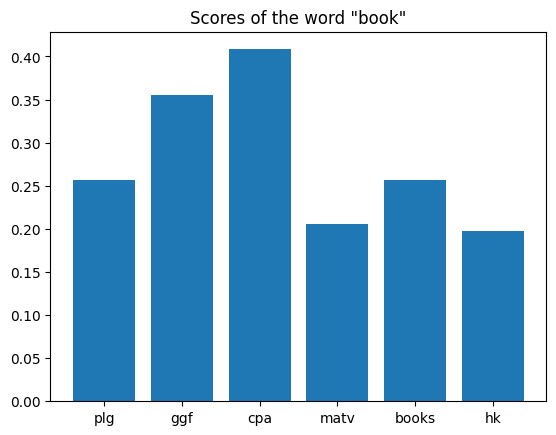

In [ ]:
# search for a specific word's score across every category and create a bar graph
# remember to leave no spaces in or around the word

a_word = str(input("Enter the word:")).lower()

all_word_scores = []

for i in range(len(dict_to_df_p)):
  for j in range(len(dict_to_df_p[i])):
    # print(dict_to_df_p[cat_index][j][0])
    if dict_to_df_p[i][j][0] == a_word:
      all_word_scores.append([test_data_pfixs[i], dict_to_df_p[i][j]])
      break

print(all_word_scores)

cats = [node[0] for node in all_word_scores]
scores = [node[1][1] for node in all_word_scores]

plt.bar(cats, scores)
plt.title(f"Scores of the word \"{a_word}\"")
plt.show()


In [ ]:
# run this to evaluate only one review

o_r_like_dislike_dict = {}

# consider word threshold for sect[i] to consider
min_word_occurrence = 140
consider_word_threshold = sorted(f_sentiment_dict.items(), key=lambda d: -d[1][1])[0][1][1] + 1
print(consider_word_threshold)

rev_title = str(input("Enter the review title:")).lower()
rev_text = str(input("Enter the review text:")).lower()

# create tokenized instances of review title and text
rev_tokens = [word_tokenize(rev_title), word_tokenize(rev_text)]
sect_num = 0
for sect in rev_tokens:
  # evaluate the sentiment of the target word
  for i in range(len(sect)):
    # evaluate for noun or unknown word
    if is_noun_or_unknown(sect[i]):
      if sect[i] not in stop_words_list:
        if (sect[i] not in f_sentiment_dict) or (f_sentiment_dict[sect[i]][1] < consider_word_threshold):
          # use the sentiment of surrounding words to weigh the target word
          for j in range(len(sect)):
            try:
              if (sect[j] not in stop_words_list) and (sect[j] in f_sentiment_dict):
                if sect[i] not in o_r_like_dislike_dict:
                  if f_sentiment_dict[sect[j]][1] > min_word_occurrence:
                    o_r_like_dislike_dict[sect[i]] = [f_sentiment_dict[sect[j]][2] / 2**(abs(i - j)), 1]
                else:
                  if f_sentiment_dict[sect[j]][1] > min_word_occurrence:
                  # print(sect[i], like_dislike_dict[sect[i]])
                    o_r_like_dislike_dict[sect[i]][0] += f_sentiment_dict[sect[j]][2] / (2**(abs(i - j)))
                    o_r_like_dislike_dict[sect[i]][1] += 1
                  # print(sect[i], like_dislike_dict[sect[i]])
            except OverflowError:
              # print("Overflow encountered while processing " + str(sect[j]) + " for " + str(sect[i]))
              break
          if sect_num == 1:
            for j in range(len(rev_tokens[0])):
              try:
                if (rev_tokens[0][j] not in stop_words_list) and (rev_tokens[0][j] in f_sentiment_dict):
                  if sect[i] not in o_r_like_dislike_dict:
                    if f_sentiment_dict[rev_tokens[0][j]][1] > min_word_occurrence:
                      o_r_like_dislike_dict[sect[i]] = [f_sentiment_dict[rev_tokens[0][j]][2], 1]
                  else:
                    if f_sentiment_dict[rev_tokens[0][j]][1] > min_word_occurrence:
                    # print(sect[i], like_dislike_dict[sect[i]])
                      o_r_like_dislike_dict[sect[i]][0] += f_sentiment_dict[rev_tokens[0][j]][2]
                      o_r_like_dislike_dict[sect[i]][1] += 1
                    # print(sect[i], like_dislike_dict[sect[i]])
              except OverflowError:
                # print("Overflow encountered while processing " + str(rev_tokens[0][j]) + " for " + str(sect[i]))
                break
  sect_num += 1
# append the averages of words into the dictionary
for node in o_r_like_dislike_dict:
  o_r_like_dislike_dict[node].append(o_r_like_dislike_dict[node][0] / o_r_like_dislike_dict[node][1])

# filter the dictionary so there are less irrelevant words
# f_like_dislike_dict = {node : like_dislike_dict[node] for node in like_dislike_dict if like_dislike_dict[node][1] > 350}

# display the results
# print(like_dislike_dict.items())
# The same topic sentiment dictionary is printed twice, but one is sorted from most negative to most positive
# and the other is vice versa.
print(sorted(o_r_like_dislike_dict.items(), key = lambda d: d[1][2]))
print(sorted(o_r_like_dislike_dict.items(), key = lambda d: -d[1][2]))

102337
Enter the review title:A very good laptop
Enter the review text:This is a very good laptop! It runs super well and is so nice!
[('laptop', [20.384361227261692, 10, 2.038436122726169])]
[('laptop', [20.384361227261692, 10, 2.038436122726169])]
